100%|██████████| 100/100 [00:02<00:00, 35.95it/s]



Metriche Bootstrap:
Training Accuracy: 0.9675 ± 0.0144
Validation Accuracy: 0.7469 ± 0.0555
Test Accuracy: 0.7876 ± 0.0665
Precision: 0.7915 ± 0.0661
Recall: 0.7876 ± 0.0665
F1-score: 0.7859 ± 0.0686

Overfitting Gap (Train - Validation): 0.2207
Overfitting Gap (Validation - Test): -0.0408


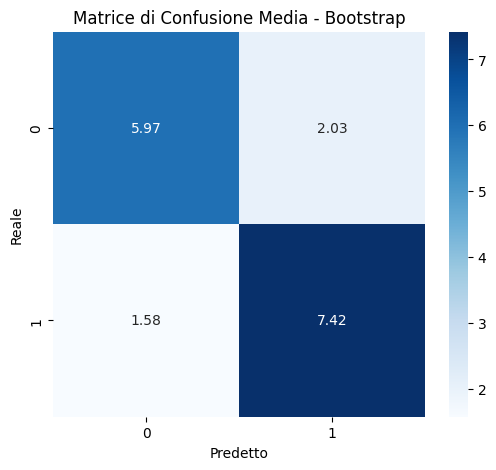

In [1]:
# Ricaricare le librerie necessarie
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

file_path = "../pre_processing_output/duplicated_nodes_main_components.csv"
df = pd.read_csv(file_path)

import ast
df["GO_embeddings"] = df["GO_embeddings"].apply(ast.literal_eval)

embeddings_df = pd.DataFrame(df["GO_embeddings"].tolist())

X = embeddings_df
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

n_iterations = 100  
accuracy_train_scores = []
accuracy_val_scores = []
accuracy_test_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
conf_matrices = []

for _ in tqdm(range(n_iterations)):
    # Bootstrapping
    X_boot, y_boot = resample(X_train, y_train, replace=True)
    
    svm_model_boot = SVC(kernel="rbf", C=10, gamma=0.001, class_weight="balanced")
    svm_model_boot.fit(X_boot, y_boot)
    
    train_acc = svm_model_boot.score(X_boot, y_boot)
    accuracy_train_scores.append(train_acc)
    val_acc = svm_model_boot.score(X_val, y_val)
    accuracy_val_scores.append(val_acc)

    y_pred = svm_model_boot.predict(X_test)
    
    test_acc = accuracy_score(y_test, y_pred)
    accuracy_test_scores.append(test_acc)
    
    precision_scores.append(precision_score(y_test, y_pred, average="weighted", zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, average="weighted", zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, average="weighted", zero_division=0))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

results = {
    "Training Accuracy": (np.mean(accuracy_train_scores, dtype='float64'), np.std(accuracy_train_scores)),
    "Validation Accuracy": (np.mean(accuracy_val_scores, dtype='float64'), np.std(accuracy_val_scores)),
    "Test Accuracy": (np.mean(accuracy_test_scores, dtype='float64'), np.std(accuracy_test_scores)),
    "Precision": (np.mean(precision_scores, dtype='float64'), np.std(precision_scores)),
    "Recall": (np.mean(recall_scores, dtype='float64'), np.std(recall_scores)),
    "F1-score": (np.mean(f1_scores, dtype='float64'), np.std(f1_scores))
}

conf_matrix_mean = np.mean(conf_matrices, dtype='float64', axis=0)

print("\nMetriche Bootstrap:")
for metric, values in results.items():
    print(f"{metric}: {values[0]:.4f} ± {values[1]:.4f}")

# Controllo Overfitting: confronto tra Training, Validation e Test
overfitting_gap_train_val = results["Training Accuracy"][0] - results["Validation Accuracy"][0]
overfitting_gap_val_test = results["Validation Accuracy"][0] - results["Test Accuracy"][0]

print(f"\nOverfitting Gap (Train - Validation): {overfitting_gap_train_val:.4f}")
print(f"Overfitting Gap (Validation - Test): {overfitting_gap_val_test:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_mean, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione Media - Bootstrap")
plt.show()


In [74]:
np.unique(y_test)

array([0, 1])